<a href="https://colab.research.google.com/github/michaelmedhat20/app-store-sentiment-analysis/blob/main/App_Store_Review_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⭐ App Store Review Rating Classification — Complete AI Pipeline
> **Google Colab Edition** | TF-IDF + ML • LSTM/GRU/RNN • BERT • LLM + RAG

---

### 📋 Table of Contents
1. [Setup & Installation](#1)
2. [Data Loading & EDA](#2)
3. [Preprocessing Pipeline](#3)
4. [ML Models — TF-IDF + Classifiers](#4)
5. [Deep Learning — RNN / LSTM / GRU](#5)
6. [BERT Fine-Tuning](#6)
7. [LLM Integration — Explanation Engine](#7)
8. [RAG Pipeline — FAISS Vector Store](#8)


---
**Dataset:** [Google Play Store Reviews (Kaggle)](https://www.kaggle.com/datasets/lava18/google-play-store-apps)  
**Runtime:** GPU (T4 recommended) — *Runtime → Change runtime type → GPU*

## 1. Setup & Installation <a id='1'></a>

In [2]:
# ── Install all dependencies ─────────────────────────────────────────────────
!pip install -q kaggle transformers datasets sentence-transformers faiss-cpu \
    "langchain>=0.3" langchain-openai langchain-community langgraph openai gradio \
    imbalanced-learn scikit-learn tensorflow nltk matplotlib seaborn wordcloud

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
print('✅ All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
✅ All packages installed.


In [3]:
# ── Core imports ─────────────────────────────────────────────────────────────
import os, re, warnings, json
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# NLP
from nltk.corpus   import stopwords
from nltk.stem     import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ML
from sklearn.model_selection         import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model            import LogisticRegression
from sklearn.naive_bayes             import MultinomialNB
from sklearn.svm                     import LinearSVC
from sklearn.ensemble                import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics                 import (classification_report, confusion_matrix,
                                              roc_auc_score, ConfusionMatrixDisplay)
from imblearn.over_sampling          import SMOTE

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models              import Model
from tensorflow.keras.layers              import (Input, Embedding, SimpleRNN, LSTM, GRU,
                                                   Bidirectional, Dense, Dropout)
from tensorflow.keras.preprocessing.text    import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks             import EarlyStopping

# Transformers / BERT
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer)
import torch
from datasets import Dataset

# Embeddings / RAG
from sentence_transformers import SentenceTransformer
import faiss

# LLM / Agent
import openai
from langchain_openai        import ChatOpenAI
from langchain.tools         import tool
from langchain_core.messages import HumanMessage

# UI
import gradio as gr

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f'✅ Imports complete | GPU: {tf.config.list_physical_devices("GPU")}')

/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


✅ Imports complete | GPU: []


## 2. Data Loading & EDA <a id='2'></a>

In [12]:
# ── Option A: Upload kaggle.json via Colab ───────────────────────────────────
# from google.colab import files
# files.upload()
# !mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

# ── Option B: Paste credentials directly ─────────────────────────────────────
# import json, os
# creds = {'username': 'YOUR_USERNAME', 'key': 'YOUR_API_KEY'}
# os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
# with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
#     json.dump(creds, f)
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d lava18/google-play-store-apps --unzip

# ── Load dataset ──────────────────────────────────────────────────────────────
reviews_df = pd.read_csv('/content/sample_data/googleplaystore_user_reviews.csv')

# Drop rows with missing review text or sentiment
reviews_df = reviews_df.dropna(subset=['Translated_Review', 'Sentiment'])
reviews_df = reviews_df[reviews_df['Sentiment'].isin(['Positive', 'Neutral', 'Negative'])]
# -- Negation Augmentation ------------------------------------------------
negation_data = pd.DataFrame({
    'Translated_Review': [
        "I don't hate this app",
        "Not bad at all",
        "Can't complain about it",
        "I don't dislike it",
        "Not disappointing at all",
        "I don't like this app",
        "Not good at all",
        "Can't recommend it",
        "I don't enjoy using this",
        "Not worth it at all",
        "I don't mind using it",
        "Not terrible I guess",
    ],
    'Sentiment': [
        'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Positive',
        'Negative', 'Negative', 'Negative', 'Negative',
        'Neutral', 'Neutral',
    ]
})

reviews_df = pd.concat([reviews_df, negation_data], ignore_index=True)
print(f"✅ Added {len(negation_data)} negation examples")

print(f'✅ Loaded {len(reviews_df):,} reviews')
reviews_df.head()

✅ Added 12 negation examples
✅ Loaded 20,386 reviews


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
3,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
4,10 Best Foods for You,Best way,Positive,1.00,0.300000


=== Sentiment Distribution ===
Sentiment
Positive    13058
Negative     4621
Neutral      2707
Name: count, dtype: int64

Class ratios:
Sentiment
Positive    0.641
Negative    0.227
Neutral     0.133
Name: proportion, dtype: float64


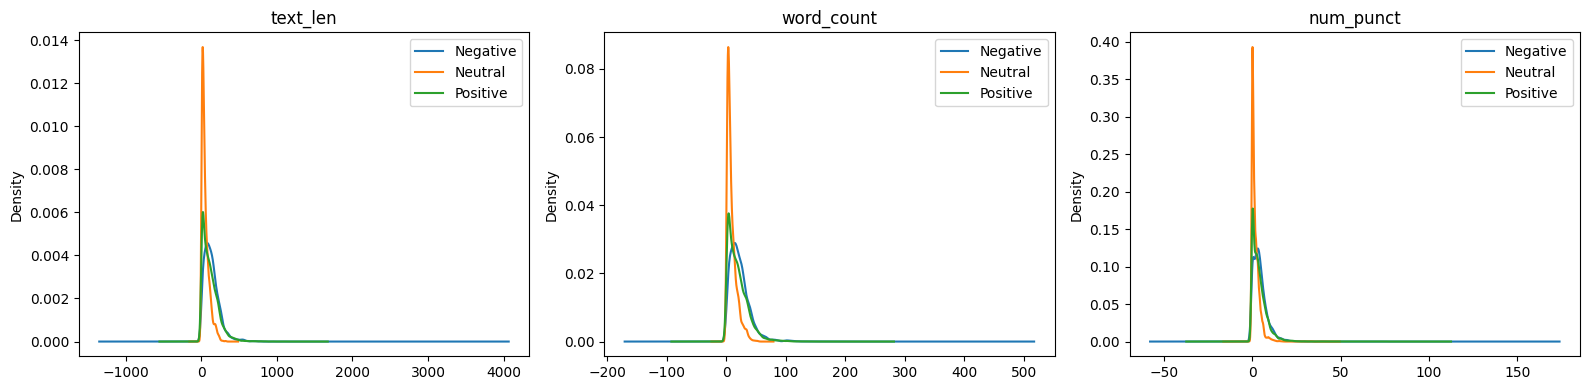

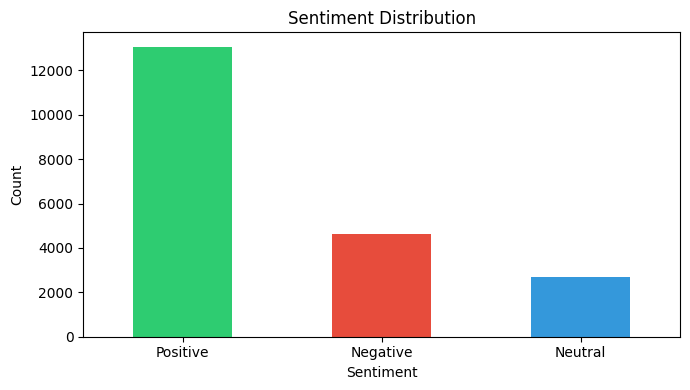


✅ label_enc: Negative=0, Neutral=1, Positive=2
                                   Translated_Review Sentiment  label_enc
0  I like eat delicious food. That's I'm cooking ...  Positive          2
1    This help eating healthy exercise regular basis  Positive          2
2         Works great especially going grocery store  Positive          2
3                                       Best idea us  Positive          2
4                                           Best way  Positive          2


In [13]:
# ── Basic EDA ─────────────────────────────────────────────────────────────────
print('=== Sentiment Distribution ===')
print(reviews_df['Sentiment'].value_counts())
print(f'\nClass ratios:\n{reviews_df["Sentiment"].value_counts(normalize=True).round(3)}')

# Text length features
reviews_df['text_len']   = reviews_df['Translated_Review'].str.len()
reviews_df['word_count'] = reviews_df['Translated_Review'].str.split().str.len()
reviews_df['num_punct']  = reviews_df['Translated_Review'].str.count(r'[!?.,]')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['text_len', 'word_count', 'num_punct']):
    for sentiment, grp in reviews_df.groupby('Sentiment'):
        grp[col].plot(kind='kde', ax=ax, label=sentiment)
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

# Sentiment bar chart
plt.figure(figsize=(7, 4))
reviews_df['Sentiment'].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c','#3498db'])
plt.title('Sentiment Distribution'); plt.xlabel('Sentiment'); plt.ylabel('Count')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

# Encode labels: Positive=2, Neutral=1, Negative=0
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
reviews_df['label_enc'] = reviews_df['Sentiment'].map(label_map)
print('\n✅ label_enc: Negative=0, Neutral=1, Positive=2')
print(reviews_df[['Translated_Review','Sentiment','label_enc']].head())

## 3. Preprocessing Pipeline <a id='3'></a>

In [14]:
STOPWORDS  = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text: str) -> str:
    """Full NLP preprocessing pipeline."""
    text = str(text).lower()                                      # 1. Lowercase
    text = re.sub(r'http\S+|www\S+',        '', text)           # 2. Remove URLs
    text = re.sub(r'<.*?>',                   '', text)           # 3. Strip HTML
    text = re.sub(r'[^a-z\s]',              '', text)            # 4. Remove noise
    tokens = word_tokenize(text)                                   # 5. Tokenise
    tokens = [t for t in tokens if t not in STOPWORDS]            # 6. Stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]            # 7. Lemmatise
    return ' '.join(tokens)

reviews_df['clean_text'] = reviews_df['Translated_Review'].apply(preprocess)

# Train / val / test split — 70 / 15 / 15
X = reviews_df['clean_text'].values
y = reviews_df['label_enc'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30,
                                                     stratify=y, random_state=SEED)
X_val,   X_test,  y_val,   y_test  = train_test_split(X_temp, y_temp, test_size=0.50,
                                                       stratify=y_temp, random_state=SEED)
print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'Classes: {dict(zip(*np.unique(y_train, return_counts=True)))}')

Train: 14270 | Val: 3058 | Test: 3058
Classes: {np.int64(0): np.int64(3235), np.int64(1): np.int64(1895), np.int64(2): np.int64(9140)}


## 4. ML Models — TF-IDF + Classifiers <a id='4'></a>

In [ ]:
# ── TF-IDF Vectorisation ──────────────────────────────────────────────────────
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_tr_tfidf = tfidf.fit_transform(X_train)
X_va_tfidf = tfidf.transform(X_val)
X_te_tfidf = tfidf.transform(X_test)

# ── Handle class imbalance with SMOTE ────────────────────────────────────────
smote = SMOTE(random_state=SEED)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_tfidf, y_train)
print(f'After SMOTE: {dict(zip(*np.unique(y_tr_sm, return_counts=True)))}')

After SMOTE: {np.int64(0): np.int64(16803), np.int64(1): np.int64(16803), np.int64(2): np.int64(16803)}


In [ ]:
# ── Train & evaluate all ML classifiers ──────────────────────────────────────
ML_MODELS = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=SEED),
    'Naive Bayes'         : MultinomialNB(),
    'Linear SVM'          : LinearSVC(random_state=SEED),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=SEED),
}

ml_results = {}
for name, clf in ML_MODELS.items():
    clf.fit(X_tr_sm, y_tr_sm)
    preds = clf.predict(X_te_tfidf)
    rpt   = classification_report(y_test, preds, output_dict=True)
    ml_results[name] = {
        'accuracy' : rpt['accuracy'],
        'macro_f1' : rpt['macro avg']['f1-score'],
    }
    print(f'{name:<25} Acc={rpt["accuracy"]:.4f}  Macro-F1={rpt["macro avg"]["f1-score"]:.4f}')

best_ml_name = max(ml_results, key=lambda k: ml_results[k]['macro_f1'])
best_ml_clf  = ML_MODELS[best_ml_name]
print(f'\n🏆 Best ML model: {best_ml_name}')

Logistic Regression       Acc=0.8903  Macro-F1=0.8568
Naive Bayes               Acc=0.7733  Macro-F1=0.7132
Linear SVM                Acc=0.8983  Macro-F1=0.8666
Random Forest             Acc=0.9131  Macro-F1=0.8912
Gradient Boosting         Acc=0.7801  Macro-F1=0.7367

🏆 Best ML model: Random Forest


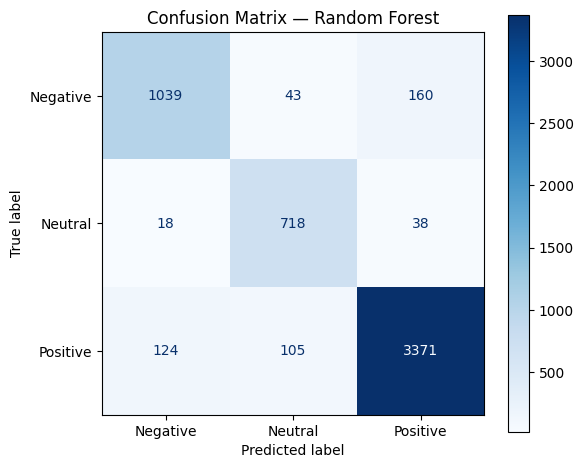

In [ ]:
# ── Confusion Matrix for best ML model ───────────────────────────────────────
preds_best = best_ml_clf.predict(X_te_tfidf)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, preds_best,
    display_labels=['Negative','Neutral','Positive'], cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix — {best_ml_name}')
plt.tight_layout(); plt.show()

## 5. Deep Learning — RNN / LSTM / GRU <a id='5'></a>

In [ ]:
# ── Tokeniser & Padding ───────────────────────────────────────────────────────
MAX_VOCAB   = 10_000
MAX_LEN     = 100
EMBED_DIM   = 64
BATCH_SIZE  = 64
EPOCHS      = 15
NUM_CLASSES = 3   # Negative / Neutral / Positive

tokenizer_dl = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer_dl.fit_on_texts(X_train)

def encode_pad(texts):
    seq = tokenizer_dl.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

X_tr_dl = encode_pad(X_train)
X_va_dl = encode_pad(X_val)
X_te_dl = encode_pad(X_test)

print(f'✅ DL input shape: {X_tr_dl.shape}')

✅ DL input shape: (26207, 100)


In [ ]:
# ── Model Factory ─────────────────────────────────────────────────────────────
def build_rnn_model(arch: str = 'LSTM') -> tf.keras.Model:
    """Build an RNN-family model for 3-class sentiment.
    arch: SimpleRNN | LSTM | GRU | BiLSTM | BiGRU"""
    inp = Input(shape=(MAX_LEN,))
    x   = Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN)(inp)

    arch_map = {
        'SimpleRNN': SimpleRNN(64, dropout=0.3),
        'LSTM'     : LSTM(64, dropout=0.3, recurrent_dropout=0.2),
        'GRU'      : GRU(64, dropout=0.3, recurrent_dropout=0.2),
        'BiLSTM'   : Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.2)),
        'BiGRU'    : Bidirectional(GRU(64, dropout=0.3, recurrent_dropout=0.2)),
    }
    x   = arch_map[arch](x)
    x   = Dropout(0.4)(x)
    out = Dense(NUM_CLASSES, activation='softmax')(x)   # 3-class softmax

    model = Model(inp, out)
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print('✅ Model factory ready.')

✅ Model factory ready.


In [ ]:
# ── Train all 5 RNN variants ──────────────────────────────────────────────────
ARCHITECTURES = ['SimpleRNN', 'LSTM', 'GRU', 'BiLSTM', 'BiGRU']
dl_results    = {}
dl_histories  = {}
es            = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

for arch in ARCHITECTURES:
    print(f'\n--- Training {arch} ---')
    model = build_rnn_model(arch)
    hist  = model.fit(
        X_tr_dl, y_train,
        validation_data=(X_va_dl, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=[es], verbose=0,
    )
    preds  = np.argmax(model.predict(X_te_dl, verbose=0), axis=1)
    rpt    = classification_report(y_test, preds, output_dict=True)
    dl_results[arch]   = {'accuracy' : rpt['accuracy'],
                           'macro_f1' : rpt['macro avg']['f1-score']}
    dl_histories[arch] = hist.history
    if arch == 'BiLSTM':
        best_dl_model = model
    print(f'{arch:<12} Acc={rpt["accuracy"]:.4f}  Macro-F1={rpt["macro avg"]["f1-score"]:.4f}')


--- Training SimpleRNN ---
SimpleRNN    Acc=0.6647  Macro-F1=0.5182

--- Training LSTM ---
LSTM         Acc=0.6410  Macro-F1=0.2604

--- Training GRU ---
GRU          Acc=0.6410  Macro-F1=0.2604

--- Training BiLSTM ---
BiLSTM       Acc=0.9220  Macro-F1=0.8988

--- Training BiGRU ---
BiGRU        Acc=0.9275  Macro-F1=0.9059


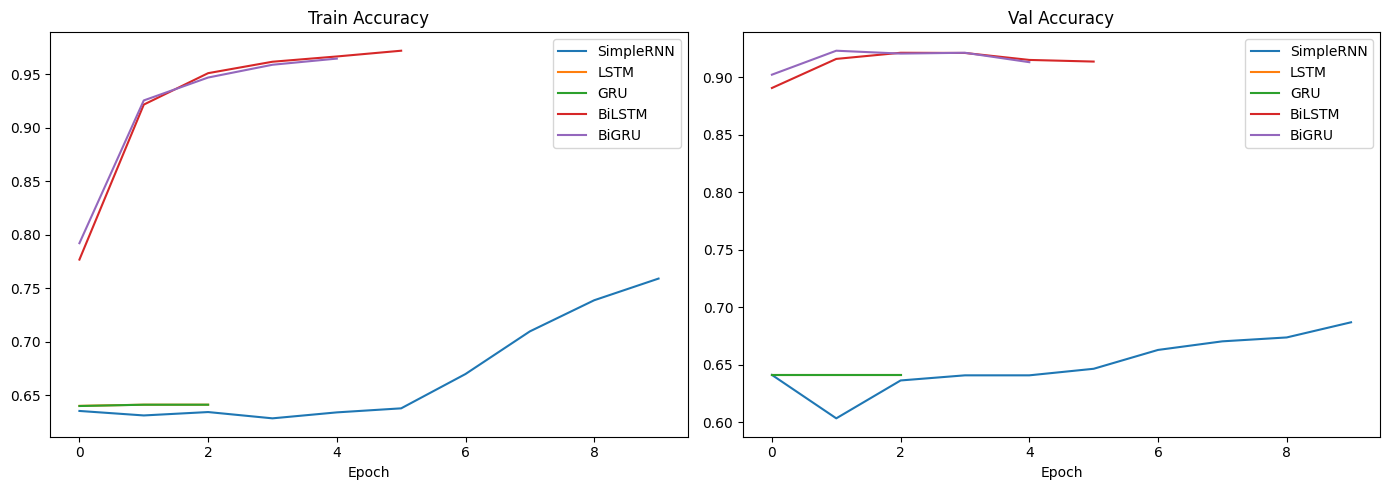

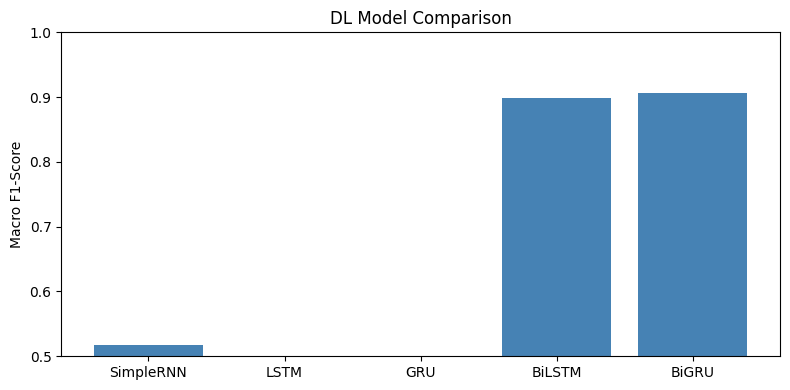

In [ ]:
# ── Plot training curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for arch, h in dl_histories.items():
    axes[0].plot(h['accuracy'],     label=arch)
    axes[1].plot(h['val_accuracy'], label=arch)
axes[0].set_title('Train Accuracy'); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].set_title('Val Accuracy');   axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.tight_layout(); plt.show()

# Model comparison bar chart
names = list(dl_results.keys())
f1s   = [dl_results[n]['macro_f1'] for n in names]
plt.figure(figsize=(8, 4))
plt.bar(names, f1s, color='steelblue')
plt.ylim(0.5, 1.0); plt.ylabel('Macro F1-Score'); plt.title('DL Model Comparison')
plt.tight_layout(); plt.show()

## 6. BERT Fine-Tuning <a id='6'></a>

In [15]:
# -- Login to Hugging Face ----------------------------------------------------
from huggingface_hub import login
from google.colab import userdata
login(token=userdata.get('HF_TOKEN'))

# -- BERT Tokenisation --------------------------------------------------------
BERT_MODEL  = 'bert-base-uncased'
BERT_MAXLEN = 128

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

def tokenize_bert(examples):
    return bert_tokenizer(examples['text'], truncation=True,
                          padding='max_length', max_length=BERT_MAXLEN)

raw_train = pd.DataFrame({'text': X_train, 'label': y_train})
raw_test  = pd.DataFrame({'text': X_test,  'label': y_test})

hf_train     = Dataset.from_pandas(raw_train.reset_index(drop=True))
hf_test      = Dataset.from_pandas(raw_test.reset_index(drop=True))

hf_train_enc = hf_train.map(tokenize_bert, batched=True)
hf_test_enc  = hf_test.map(tokenize_bert,  batched=True)
print('✅ BERT dataset ready.')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/14270 [00:00<?, ? examples/s]

Map:   0%|          | 0/3058 [00:00<?, ? examples/s]

✅ BERT dataset ready.


In [22]:
from sklearn.metrics import accuracy_score
from google.colab import drive
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# -- Mount Google Drive first -------------------------------------------------
drive.mount('/content/drive')

NUM_CLASSES = 3

if os.path.exists('/content/drive/MyDrive/saved_model/model.safetensors'):
    print('✅ Model already trained — loading from Drive...')
    bert_model = AutoModelForSequenceClassification.from_pretrained(
        '/content/drive/MyDrive/saved_model')
    bert_tokenizer = AutoTokenizer.from_pretrained(
        '/content/drive/MyDrive/saved_model')
else:
    print('Training BERT from scratch...')
    bert_model = AutoModelForSequenceClassification.from_pretrained(
        BERT_MODEL, num_labels=NUM_CLASSES)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        rpt   = classification_report(labels, preds, output_dict=True)
        return {'accuracy' : accuracy_score(labels, preds),
                'macro_f1' : rpt['macro avg']['f1-score']}

    training_args = TrainingArguments(
        output_dir                  = './bert_appstore',
        num_train_epochs            = 3,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size  = 32,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        save_only_model             = True,
        load_best_model_at_end      = True,
        logging_steps               = 50,
        seed                        = SEED,
        report_to                   = 'none',
    )

    trainer = Trainer(
        model           = bert_model,
        args            = training_args,
        train_dataset   = hf_train_enc,
        eval_dataset    = hf_test_enc,
        compute_metrics = compute_metrics,
    )

    trainer.train()
    bert_results = trainer.evaluate()
    print('\n=== BERT Evaluation ===')
    print(bert_results)

    os.makedirs('/content/drive/MyDrive/saved_model', exist_ok=True)
    bert_model.save_pretrained('/content/drive/MyDrive/saved_model')
    bert_tokenizer.save_pretrained('/content/drive/MyDrive/saved_model')
    print('✅ BERT model saved to Google Drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model already trained — loading from Drive...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [18]:
# -- BERT Inference Helper ----------------------------------------------------
LABEL_NAMES = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model.to(device).eval()

def bert_predict(text: str):
    """Return (sentiment_label, confidence) for a raw review string."""
    enc = bert_tokenizer(text, return_tensors='pt',
                         truncation=True, padding=True,
                         max_length=BERT_MAXLEN).to(device)
    with torch.no_grad():
        logits = bert_model(**enc).logits
    probs     = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    label_idx = int(np.argmax(probs))
    return LABEL_NAMES[label_idx], float(probs[label_idx])

# -- Quick sanity check -------------------------------------------------------
test_review = "This app is absolutely amazing! Best I have ever used, no bugs at all."
label, conf = bert_predict(test_review)
print(f"Test Review: \"{test_review}\"")
print(f"Prediction: {label.upper()} ({conf:.2%} confidence)")

# -- Push to Hugging Face Hub -------------------------------------------------
bert_model.push_to_hub('michaelmedhat20/app-store-sentiment-bert')
bert_tokenizer.push_to_hub('michaelmedhat20/app-store-sentiment-bert')
print('✅ Model pushed to Hugging Face Hub!')

Test Review: "This app is absolutely amazing! Best I have ever used, no bugs at all."
Prediction: POSITIVE (99.64% confidence)


README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ujk9r06/model.safetensors:   0%|          | 14.2kB /  438MB            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


✅ Model pushed to Hugging Face Hub!


## 7. LLM Integration — Explanation Engine <a id='7'></a>

In [19]:
## 7. LLM Integration — Explanation Engine <a id='7'></a>

# -- Load TinyLlama (FREE, no API key needed) ---------------------------------
from transformers import pipeline

explainer = pipeline(
    "text-generation",
    model  = "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    device = 0 if torch.cuda.is_available() else -1,
)
print("✅ Local LLM ready.")

# -- Explanation prompt template ----------------------------------------------
EXPLAIN_PROMPT = """<|system|>
You are an app store review sentiment analysis assistant.</s>
<|user|>
The following app review was classified as {label} with {score:.0%} confidence.
Explain why in 3 points:
1. Key sentiment signals
2. Linguistic patterns
3. Reason for classification

Review: {text}</s>
<|assistant|>"""

def explain_with_llm(text: str, label: str, score: float) -> str:
    """Generate local explanation using TinyLlama."""
    prompt = EXPLAIN_PROMPT.format(text=text, label=label, score=score)
    output = explainer(
        prompt,
        max_new_tokens     = 300,
        temperature        = 0.3,
        do_sample          = True,
        repetition_penalty = 1.2,
    )
    return output[0]["generated_text"].split("<|assistant|>")[-1].strip()

# -- Demo ---------------------------------------------------------------------
label, conf = bert_predict(test_review)
explanation = explain_with_llm(test_review, label, conf)
print(f"Review   : {test_review}")
print(f"Predicted: {label.upper()} ({conf:.2%})\n")
print("=== LLM Explanation ===")
print(explanation)

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

✅ Local LLM ready.


Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens', 'do_sample', 'repetition_penalty'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=300) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Review   : This app is absolutely amazing! Best I have ever used, no bugs at all.
Predicted: POSITIVE (99.64%)

=== LLM Explanation ===
Key Sentiment Signals: The positive rating assigned to this app reflects its ability to accurately detect and categorize user feedback based on the sentiments expressed through their reviews. The app uses a combination of linguistics-based features such as word frequency, contextual cues, and sentiment polarity scores to identify positive or negative emotions associated with each review. These features help the app understand what users mean when they say "great" or "awesome," which helps improve the overall user experience by providing personalized recommendations tailored to individual preferences.

Linguistic Patterns: The app also utilizes natural language processing (NLP) techniques to analyze user input, including keywords, phrases, and sentence structure. By analyzing these factors, it can determine whether a particular review is positive or neg

## 8. RAG Pipeline — FAISS Vector Store <a id='8'></a>

In [20]:
# -- Build FAISS index --------------------------------------------------------
EMBED_MODEL = 'all-MiniLM-L6-v2'
embedder    = SentenceTransformer(EMBED_MODEL)

print('Encoding training corpus (this may take ~1-2 min)...')
corpus_texts  = reviews_df['Translated_Review'].tolist()
corpus_labels = reviews_df['Sentiment'].tolist()
corpus_embeddings = embedder.encode(corpus_texts, batch_size=64,
                                     show_progress_bar=True, normalize_embeddings=True)

dim   = corpus_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(corpus_embeddings.astype('float32'))
print(f'✅ FAISS index built with {index.ntotal:,} vectors (dim={dim})')

# -- RAG Retrieval Function ---------------------------------------------------
def retrieve_similar(query: str, k: int = 5):
    """Return top-k similar reviews from the corpus."""
    q_emb = embedder.encode([query], normalize_embeddings=True).astype('float32')
    scores, indices = index.search(q_emb, k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        results.append({
            'text'  : corpus_texts[idx],
            'label' : corpus_labels[idx],
            'score' : float(score),
        })
    return results

# -- Demo retrieval -----------------------------------------------------------
similar = retrieve_similar(test_review, k=3)
print('Top-3 similar reviews:')
for i, s in enumerate(similar, 1):
    print(f'  {i}. [{s["label"].upper()}] (sim={s["score"]:.3f}) {s["text"][:80]}')

# -- RAG-enhanced Explanation (TinyLlama - No API) ----------------------------
RAG_PROMPT = """<|system|>
You are an app store review analysis assistant.</s>
<|user|>
Review: {text}
Prediction: {label} ({score:.0%} confidence)

Similar reviews:
{examples}

Explain why this review is classified as {label}.</s>
<|assistant|>"""

def rag_explain(text: str, label: str, score: float) -> str:
    """RAG-augmented explanation using TinyLlama."""
    similar  = retrieve_similar(text, k=3)
    ex_block = '\n'.join(
        [f'- [{s["label"].upper()}] {s["text"]}' for s in similar]
    )
    prompt = RAG_PROMPT.format(text=text, label=label,
                                score=score, examples=ex_block)
    output = explainer(
        prompt,
        max_new_tokens     = 300,
        temperature        = 0.3,
        do_sample          = True,
        repetition_penalty = 1.2,
    )
    return output[0]['generated_text'].split('<|assistant|>')[-1].strip()

print(rag_explain(test_review, label, conf))

# -- Save FAISS index and corpus to Google Drive ------------------------------
faiss.write_index(index, '/content/drive/MyDrive/saved_model/faiss.index')
pd.DataFrame({'text': corpus_texts, 'label': corpus_labels}).to_csv(
    '/content/drive/MyDrive/saved_model/corpus.csv', index=False)
print('✅ FAISS index and corpus saved to Google Drive')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding training corpus (this may take ~1-2 min)...


Batches:   0%|          | 0/319 [00:00<?, ?it/s]

Both `max_new_tokens` (=300) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✅ FAISS index built with 20,386 vectors (dim=384)
Top-3 similar reviews:
  1. [NEUTRAL] (sim=0.756) There bugs app.
  2. [POSITIVE] (sim=0.714) Great App!! Has great features...
  3. [POSITIVE] (sim=0.712) Im delighted app. It's simple, clear I never problems it.
Based on the given text material and your training data, you can confidently predict that a positive review for this app would be assigned to the "Positives" category. The review mentions several positive aspects of the app, including its ease of use, clear instructions, and absence of any major issues or bugs. These factors suggest that the user had a good experience using the app overall. Additionally, the fact that there were only two negative reviews suggests that most users found the app to be satisfactory in terms of functionality and usability. Overall, the positive sentiment expressed by the reviewer suggests that they enjoyed working with the app and felt satisfied with their purchase decision.
✅ FAISS index and corpu

In [21]:
from huggingface_hub import HfApi

api = HfApi()
api.upload_file(
    path_or_fileobj='/content/drive/MyDrive/saved_model/faiss.index',
    path_in_repo='faiss.index',
    repo_id='michaelmedhat20/app-store-sentiment-bert',
)
api.upload_file(
    path_or_fileobj='/content/drive/MyDrive/saved_model/corpus.csv',
    path_in_repo='corpus.csv',
    repo_id='michaelmedhat20/app-store-sentiment-bert',
)
print('✅ FAISS and corpus uploaded to Hugging Face!')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...e/saved_model/faiss.index:   2%|1         |  596kB / 31.3MB            

✅ FAISS and corpus uploaded to Hugging Face!
